In [2]:
# Manuscript Figure 4 / Supp Figure 5 -----------------------------------------
#------------------------------------------------------------------------------

library(Seurat)
library(patchwork)
library(dplyr)
library(data.table)
library(AUCell)
library(GSEABase)
library(ggplot2)
library(reshape2)
library(patchwork)
library(readxl)

proj_dir = '/Aging/'
data_dir <- '/singleCell/Kamath2022_DAneuron/snRNA-seq/processed/'
data_dir2 <- '/Aging/Data/Kamath2022/'
data_dir3 <- '/Aging/Aging_Clock/Output/'

PLOTDIR <- '/Aging/Aging_Clock/Plots/'
setwd(PLOTDIR)

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: Biobase

Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', and for packa

In [3]:
# START HERE ------------------------------------------------------------------------------
# DOWNSTREAM ANALYSIS AFTER AUCELL

query <- readRDS(paste0(data_dir2,"Kamath2022_DAneuron_snRNA_hs_processed_AUCell.rds"))

In [34]:
colnames(query@meta.data)
query
query@meta.data %>%
group_by(Status) %>%
summarize(
    min=min(Donor_Age, na.rm=T), max=max(Donor_Age, na.rm=T), Donors=length(unique(donor_id))
)

[1] "orig.ident"                                  
 [2] "nCount_RNA"                                  
 [3] "nFeature_RNA"                                
 [4] "Id"                                          
 [5] "X"                                           
 [6] "Y"                                           
 [7] "Cell_Type"                                   
 [8] "libname"                                     
 [9] "biosample_id"                                
[10] "donor_id"                                    
[11] "species"                                     
[12] "species__ontology_label"                     
[13] "disease"                                     
[14] "disease__ontology_label"                     
[15] "organ"                                       
[16] "organ__ontology_label"                       
[17] "library_preparation_protocol"                
[18] "library_preparation_protocol__ontology_label"
[19] "sex"                                         
[20] "date"                                        
[21] "Donor_Age"                                   
[22] "Donor_PMI"                                   
[23] "Status"                                      
[24] "Cause_of_Death"                              
[25] "FACS_Classification"                         
[26] "RNA_snn_res.0.5"                             
[27] "seurat_clusters"                             
[28] "pos0_cr.x"                                   
[29] "neg0_cr.x"                                   
[30] "pos9_cr.x"                                   
[31] "neg9_cr.x"                                   
[32] "pos0.x"                                      
[33] "neg0.x"                                      
[34] "pos24.x"                                     
[35] "neg24.x"                                     
[36] "dna_damage.x"                                
[37] "can_sen.x"                                   
[38] "sen_init.x"                                  
[39] "sen_resp.x"                                  
[40] "cellage.x"                                   
[41] "geneset_sc0"                                 
[42] "geneset_sc24"                                
[43] "geneset_sc0_class"                           
[44] "geneset_sc24_class"                          
[45] "pos0.y"                                      
[46] "neg0.y"                                      
[47] "pos24.y"                                     
[48] "neg24.y"                                     
[49] "pos0_cr.y"                                   
[50] "neg0_cr.y"                                   
[51] "pos9_cr.y"                                   
[52] "neg9_cr.y"                                   
[53] "dna_damage.y"                                
[54] "can_sen.y"                                   
[55] "sen_init.y"                                  
[56] "sen_resp.y"                                  
[57] "cellage.y"

An object of class Seurat 
38595 features across 22048 samples within 1 assay 
Active assay: RNA (38595 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

Status,min,max,Donors
<chr>,<chr>,<chr>,<int>
Ctrl,49,92,8
LBD,70,89,4
PD,76,90,6


In [122]:
#DimPlot(query)
# DA UMAP (based on paper's analysis)
#query@meta.data[,c('X','Y')] <- lapply(query@meta.data[,c('X','Y')], as.numeric)
#query@meta.data[,c('geneset_sc0','geneset_sc24')] <- lapply(query@meta.data[,c('geneset_sc0','geneset_sc24')], as.numeric)

#colnames(query@assays$RNA)
#rownames(query@meta.data) <- query@meta.data$Id
query1 <- subset(query, subset = Status != 'LBD')

custom_palette <- c(
"#9ec6ba", "#a4ebc5", "#b5b477", "#aecdc4", "#825ca9",
"#7f7f7f", "#6e6e6d", "#555555", "#eec3e0", "#689e73","#a4ebbb"
)

setwd(PLOTDIR)
pdf('DimPlot_Kamath_DAneurons_sc0_sc24.pdf', width=5,height=5)
FeatureScatter(query1, feature1 = "X", feature2 = "Y", group.by='Cell_Type', cols = custom_palette) + NoLegend()
FeatureScatter(query1, feature1 = "X", feature2 = "Y", group.by='geneset_sc0', cols = colorRampPalette(c('#000435','#FFCBA4','#21FE80'))(ncol(query))) + NoLegend()
FeatureScatter(query1, feature1 = "X", feature2 = "Y", group.by='geneset_sc0', split.by = 'Status', cols = colorRampPalette(c('#000435','#FFCBA4','#21FE80'))(ncol(query))) + NoLegend()
FeatureScatter(query1, feature1 = "X", feature2 = "Y", group.by='geneset_sc24', split.by = 'Status',cols = colorRampPalette(c('#000435','#FFCBA4','#21FE80'))(ncol(query))) + NoLegend()
dev.off()

pdf 
  2

In [20]:
#DimPlot(query)
# DA UMAP (based on paper's analysis)
query@meta.data[,c('X','Y')] <- lapply(query@meta.data[,c('X','Y')], as.numeric)
query@meta.data[,c('geneset_sc0','geneset_sc24')] <- lapply(query@meta.data[,c('geneset_sc0','geneset_sc24')], as.numeric)

#colnames(query@assays$RNA)
rownames(query@meta.data) <- query@meta.data$Id
#query1 <- subset(query, subset = Status != 'LBD')

custom_palette <- c(
"#9ec6ba", "#a4ebc5", "#b5b477", "#aecdc4", "#825ca9",
"#7f7f7f", "#6e6e6d", "#555555", "#eec3e0", "#689e73","#a4ebbb"
)

setwd(PLOTDIR)
pdf('DimPlot_Kamath_DAneurons_sc0_sc24_MT_OXPH_all.pdf', width=12,height=5)

genes <- c('geneset_sc0', 'geneset_sc24',
               'MT-ND1', 'MT-CO1','NDUFV1','COX5B', 'CHCHD10')
# Loop over each gene
for (gene in genes) {
  p <- FeatureScatter(
    query, 
    feature1 = "X", 
    feature2 = "Y", 
    pt.size = 0.5, 
    group.by = gene, 
    split.by = 'Status', 
    cols = colorRampPalette(c('#000435', '#FFCBA4', '#21FE80'))(ncol(query))
  ) + NoLegend()
  
  print(p + ggtitle(gene))
}

dev.off()

pdf 
  2

In [18]:
#DimPlot(query)
# DA UMAP (based on paper's analysis)
#query@meta.data[,c('X','Y')] <- lapply(query@meta.data[,c('X','Y')], as.numeric)
#rownames(query@meta.data) <- query@meta.data$Id
#query1 <- subset(query, subset = Status != 'LBD')

custom_palette <- c(
"#9ec6ba", "#a4ebc5", "#b5b477", "#aecdc4", "#825ca9",
"#7f7f7f", "#6e6e6d", "#555555", "#eec3e0", "#689e73","#a4ebbb"
)

setwd(PLOTDIR)
pdf('DimPlot_Kamath_DAneurons_RGS_all.pdf', width=12,height=5)
# Your gene list
rgs_genes <- c('RGS1', 'RGS10', 'RGS11', 'RGS12', 'RGS13', 'RGS14', 'RGS16', 'RGS17', 
               'RGS18', 'RGS19', 'RGS2', 'RGS20', 'RGS21', 'RGS22', 'RGS3', 'RGS4', 
               'RGS5', 'RGS5.1', 'RGS6', 'RGS7', 'RGS7BP', 'RGS8', 'RGS9', 'RGS9BP', 
               'RGSL1')
# Loop over each gene
for (gene in rgs_genes) {
  p <- FeatureScatter(
    query, 
    feature1 = "X", 
    feature2 = "Y", 
    pt.size = 0.5, 
    group.by = gene, 
    split.by = 'Status', 
    cols = colorRampPalette(c('#000435', '#FFCBA4', '#21FE80'))(ncol(query))
  ) + NoLegend()
  
  print(p + ggtitle(gene))
}

dev.off()

pdf 
  2

In [121]:
pdf('DimPlot_Kamath_DAneurons_sc0_scale.pdf', width=2,height=3)
# Define the number of colors and create a color palette
num_colors <- ncol(query)
custom_palette <- colorRampPalette(c('#000435','#FFCBA4','#21FE80'))(num_colors)
# Create a data frame for the color scale
color_scale_data <- data.frame(
  x = 1,
  y = seq(0, 1, length.out = num_colors),
  value = seq(min(query1$geneset_sc0, na.rm = TRUE), max(query1$geneset_sc0, na.rm = TRUE), length.out = num_colors)
)
# Plot the color scale
ggplot(color_scale_data, aes(x = x, y = y, fill = value)) +
  geom_tile() +
  scale_fill_gradientn(colors = custom_palette, 
                       name = "geneset_sc0", 
                       limits = c(min(query1$geneset_sc0, na.rm = TRUE), max(query1$geneset_sc0, na.rm = TRUE)),
                       na.value = "grey") +
  theme_void() +  # Remove axes and background
  theme(legend.position = "right")  # Adjust legend position
dev.off()

pdf 
  2

Warning message:
“The input is a data frame-like object, convert it to a matrix.”


pdf 
  2

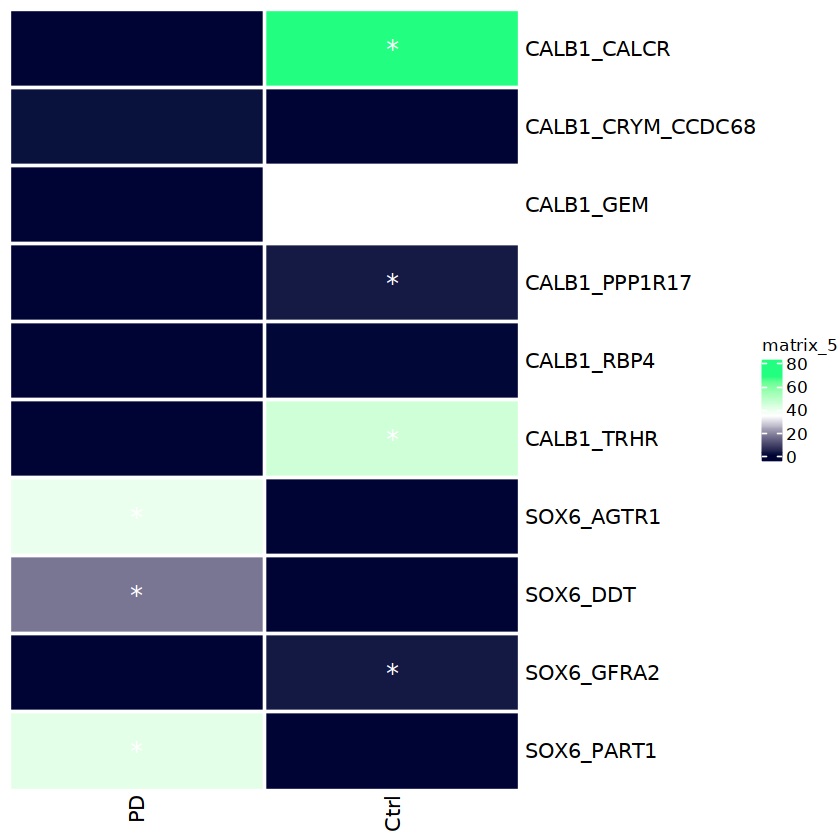

In [110]:
# Celltype Composition -----------------------------------------------------------

# Hypergeomtric test -------------------------------------------------------------
# --------------------------------------------------------------------------------
# PD
metadata_pd <- query1@meta.data[query1@meta.data['Status'] == 'PD',]
tbl_pd <- as.data.frame(table(unclass(metadata_pd$Cell_Type)))
colnames(tbl_pd)[2] <- 'Freq_PD'
# Ctrl
metadata_ctrl <- query1@meta.data[query1@meta.data['Status'] == 'Ctrl',]
tbl_ctrl <- as.data.frame(table(unclass(metadata_ctrl$Cell_Type)))
colnames(tbl_ctrl)[2] <- 'Freq_Ctrl'
# Merge tables
tbl <- Reduce(function(x, y) merge(x, y, by = 'Var1', all = TRUE), list(tbl_pd, tbl_ctrl))
tbl[is.na(tbl)] <- 0
status <- c('PD', 'Ctrl')
celltypes <- tbl$Var1
df1 <- data.frame()
for (s in seq_along(status)) {
  df2 <- data.frame()
  for (c in seq_along(celltypes)) {
    m_plus_n <- sum(tbl$Freq_PD, tbl$Freq_Ctrl)
    m <- sum(tbl[tbl$Var1 == celltypes[c], 2:3])
    k <- sum(tbl[[paste0('Freq_', status[s])]])
    q <- tbl[tbl$Var1 == celltypes[c], paste0('Freq_', status[s])]
    phyper <- phyper(q, m, m_plus_n - m, k, lower.tail = TRUE, log.p = FALSE) ## lower.tail=F overrep / lower.tail=T underrep
    df3 <- data.frame(Cell_Type = celltypes[c], m_plus_n, m, k, q, phyper)
    df2 <- rbind(df2, df3)
  } 
  df2$BH <- p.adjust(df2$phyper, method = 'BH')
  df2$log10 <- -log10(df2$BH)
  colnames(df2)[c(2:8)] = paste0(colnames(df2)[c(2:8)],"_",status[s])
  df1 <- if (s > 1) merge(df1, df2, by = 'Cell_Type', all = TRUE) else df2
}
rownames(df1) <- df1$Cell_Type
df <- df1[,which(names(df1) %like% 'log10')]
colnames(df) <- gsub('log10_','',colnames(df))             
df[] <- lapply(df, function(x) as.numeric(gsub("Inf", 300, x)))
celltype_composition <- df # save for merging with signature enrichment results later                
# --------------------------------------------------------------------------------
# Plot

#pdf(paste0(PLOTDIR, 'Heatmap.Kamath_PD_celltype_composition_underrep.pdf'), width = 4, height = 4)
library(ComplexHeatmap)
Heatmap(df, cluster_rows = FALSE, cluster_columns = FALSE, 
        col = c("#000435", "#FFFFFF", "#21FE80"),
        cell_fun = function(j, i, x, y, w, h, fill) {
          grid.rect(x, y, w, h, gp = gpar(col = "white", lwd = 2, fill = NA))
          if (df[i, j] > 1.5) {
            grid.text('*', x, y, gp = gpar(col = "white", fontsize = 15))
          }
        })
#dev.off()              
# --------------------------------------------------------------------------------
               
# Ratio --------------------------------------------------------------------------
# --------------------------------------------------------------------------------
# Ratio = proportion of celltype in group relative to its proprtion in total population 
# High = more prevalent in group 
# Low = less prevalent in total population 
df1$ratio_PD <- (df1$q_PD/df1$k_PD)/(df1$m_PD/df1$m_plus_n_PD)
df1$ratio_Ctrl <- (df1$q_Ctrl/df1$k_Ctrl)/(df1$m_Ctrl/df1$m_plus_n_Ctrl)
df1 <- df1[,c(1,16:17)]
colnames(df1) <- gsub('ratio_','',colnames(df1))              
# --------------------------------------------------------------------------------

# Reorder celltype based on ratio_PD
df1_long <- reshape2::melt(df1, id.vars = "Cell_Type", 
                           variable.name = "Condition", 
                           value.name = "Ratio")               
df1_long$Cell_Type <- factor(df1_long$Cell_Type, 
                            levels = df1$Cell_Type[order(df1$PD)])


pdf(paste0(PLOTDIR, 'Scatterplot.Kamath_PD_only_celltype_composition_ratio.pdf'), width = 4, height = 5)
              
ggplot(df1_long, aes(x = Cell_Type, y = Ratio, color = Condition, group = Condition, fill = Condition)) +
  geom_point(size = 5, alpha = 0.8, shape = 21, stroke = 0.8) +  # Add points with fill and outline
  geom_line(size = 1, alpha = 0.8) +  # Connect the dots with lines
  scale_color_manual(values = rep('#000435',3)) +  # Set colors for outline
  scale_fill_manual(values = c("#21FE80","#000435", "#FFFFFF")) +  # Set colors for fill
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(x = "Cell Type", y = "Ratio")
dev.off()